# Setup

In [1]:
!pip install -r requirements.txt
!pip install -e sliced_normals


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Obtaining file:///Users/arindamroychowdhury/Documents/Projects/NASA/DS_Submission/NASA_LOC/sliced_normals
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sliced_normals (pyproject.toml) ... done
  Created wheel for sliced_normals: filename=sliced_normals-0.1-0.editable-py3-none-any.whl size=2802 sha256=c1a06909687b61a3c240c233c129b2ad799412cf12f6e8346ce5dcc37a6886b1
  Stored in directory: /private/var/folders/g9/80x8n1z527vb5m0fv7hnktvc0000gn/T/pip-ephem-wheel-cache-9jte3oyi/wheels/56/94/45/3baab08bb2c7f7f596ad225eabf2f59e4af3725497f1b46c8f
Successfully built sliced_normals
  Attempting uninstall: sliced_normals
    Found existing installation: sliced_normals 0.1
    Uninstalling sliced_normals-0

In [2]:
import sliced_normals as SN
from sliced_normals.fmle import get_FMLE
from sliced_normals.optimization import estimate_optimal_B
from sliced_normals.optimization import compute_integral
from sliced_normals.mcmc import run_mcmc_sampler
from sliced_normals.likelihood import evaluate_true_log_likelihood
from sliced_normals.clustering import *
from sliced_normals.features import get_F_and_Random_Samples

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import autograd.numpy as np
from autograd import grad

import pickle

In [3]:
import os
import pickle
import hashlib


import autograd.numpy as np
from autograd.numpy.linalg import inv, cholesky
from autograd.scipy.special import logsumexp

from pymanopt import Problem
from pymanopt.manifolds import Euclidean
from pymanopt.optimizers import SteepestDescent
import pymanopt.function

# Helper Functions

## Individual Group Optimization

In [4]:
def save_or_load_B_opt(data, degree, n_grid, verbosity, penalty_lambda,
                       winsor_threshold, max_iterations, min_gradient_norm,
                       seed=None, folder='temp_files'):
    """
    Loads B_opt from cache if available for the same data content, column names,
    seed, and parameters; otherwise computes and saves it using a hash-based identifier.

    Parameters:
        data : pd.DataFrame or np.ndarray
        seed : int or None, used for reproducibility if stochastic elements exist
        All other arguments are optimization parameters

    Returns:
        B_opt : np.ndarray
    """
    os.makedirs(folder, exist_ok=True)

    # Convert data to array and capture column names if present
    data_array = np.asarray(data)
    col_names = list(data.columns) if hasattr(data, "columns") else []

    # Build parameter dictionary including seed and column names
    param_dict = {
        "data_hash": hashlib.md5(data_array.tobytes()).hexdigest(),
        "column_names": col_names,
        "degree": degree,
        "n_grid": n_grid,
        "verbosity": verbosity,
        "penalty_lambda": penalty_lambda,
        "winsor_threshold": winsor_threshold,
        "max_iterations": max_iterations,
        "min_gradient_norm": min_gradient_norm,
        "seed": seed
    }

    # Generate unique hash
    param_bytes = pickle.dumps(param_dict)
    param_hash = hashlib.md5(param_bytes).hexdigest()

    # File paths
    b_path = os.path.join(folder, f'B_opt_{param_hash}.pkl')
    p_path = os.path.join(folder, f'params_{param_hash}.pkl')

    # Load if already computed
    if os.path.exists(b_path) and os.path.exists(p_path):
        with open(b_path, 'rb') as f:
            B_opt = pickle.load(f)
        print(f"✅ Loaded B_opt from cache: {b_path}")
    else:
        print("🔁 Computing B_opt (no cache found)...")
        if seed is not None:
            np.random.seed(seed)
        B_opt = estimate_optimal_B(
            data,
            degree=degree,
            n_grid=n_grid,
            verbosity=verbosity,
            penalty_lambda=penalty_lambda,
            winsor_threshold=winsor_threshold,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm
        )
        with open(b_path, 'wb') as f:
            pickle.dump(B_opt, f)
        with open(p_path, 'wb') as f:
            pickle.dump(param_dict, f)
        print(f"✅ Saved B_opt and parameters to: {b_path}")

    return B_opt


## Combine subgroups

### Main Optimization Function

In [5]:
def estimate_optimal_P12_reparam(
    Y1, Y2, Y1g, Y2g, volume,
    P11, P22,
    verbosity=2,
    max_iterations=1000,
    min_gradient_norm=1e-4,
    winsor_threshold=1e-10,
    return_details=False,
    n_restarts=1,              # NEW: number of additional random restarts after default run
    random_state=None          # NEW: reproducibility for random restarts
):
    """
    Final objective (Eq. 21) + winsorization, with multi-start optimization.

    Optimization schedule:
      1) Run once with the default initialization U0 = 0 (original behavior)
      2) Run `n_restarts` additional optimizations with U0 ~ N(0,1) entrywise
      3) Return the best solution (lowest objective value among finite runs)

    Objective:
        min_U  (1/n) * sum_i [ y1_i^T P12(U) y2_i ]
             + log( (volume/m) * sum_j w_j * exp(-2 y1g_j^T P12(U) y2g_j) )

    with
        w_j = exp( - y1g_j^T P11 y1g_j - y2g_j^T P22 y2g_j )

    and winsorized log-integral:
        log_integral <- max(log_integral, log(winsor_threshold))
    """
    n, d1 = Y1.shape
    n2, d2 = Y2.shape
    m, d1g = Y1g.shape
    m2, d2g = Y2g.shape

    if n2 != n:
        raise ValueError("Y1 and Y2 must have the same number of rows.")
    if m2 != m:
        raise ValueError("Y1g and Y2g must have the same number of rows.")
    if d1g != d1 or d2g != d2:
        raise ValueError("Grid feature dimensions must match data feature dimensions.")
    if winsor_threshold <= 0:
        raise ValueError("winsor_threshold must be positive.")
    if volume <= 0:
        raise ValueError("volume must be positive.")
    if n_restarts < 0:
        raise ValueError("n_restarts must be >= 0.")

    L1 = cholesky(P11)
    L2 = cholesky(P22)

    # log w_j = - y1g^T P11 y1g - y2g^T P22 y2g
    q11_g = np.sum((Y1g @ P11) * Y1g, axis=1)
    q22_g = np.sum((Y2g @ P22) * Y2g, axis=1)
    log_w = -(q11_g + q22_g)

    manifold = Euclidean(d1, d2)

    @pymanopt.function.autograd(manifold)
    def cost(U):
        C = contraction(U)
        P12 = L1 @ C @ L2

        # Data term: (1/n) sum y1_i^T P12 y2_i   <-- no factor 2
        cross_data = np.sum((Y1 @ P12) * Y2, axis=1)
        term1 = np.mean(cross_data)

        # Log integral term: log( (volume/m) sum_j w_j exp(-2 cross_grid_j) )
        cross_grid = np.sum((Y1g @ P12) * Y2g, axis=1)
        raw_log_int = logsumexp(log_w - 2.0 * cross_grid) - np.log(m) + np.log(volume)

        # Winsorization
        log_integral = np.maximum(raw_log_int, np.log(winsor_threshold))

        return term1 + log_integral

    def _run_single(U0, run_verbosity):
        problem = Problem(manifold=manifold, cost=cost)
        optimizer = SteepestDescent(
            verbosity=run_verbosity,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm
        )
        result = optimizer.run(problem, initial_point=U0)

        U_opt = result.point
        C_opt = contraction(U_opt)
        P12_opt = L1 @ C_opt @ L2

        cross_data_opt = np.sum((Y1 @ P12_opt) * Y2, axis=1)
        term1_opt = np.mean(cross_data_opt)

        cross_grid_opt = np.sum((Y1g @ P12_opt) * Y2g, axis=1)
        raw_log_int_opt = logsumexp(log_w - 2.0 * cross_grid_opt) - np.log(m) + np.log(volume)
        log_integral_opt = np.maximum(raw_log_int_opt, np.log(winsor_threshold))

        obj_opt = term1_opt + log_integral_opt

        details = {
            "U_opt": U_opt,
            "C_opt": C_opt,
            "term1_opt": term1_opt,
            "raw_log_integral_opt": raw_log_int_opt,
            "winsorized_log_integral_opt": log_integral_opt,
            "objective_opt": obj_opt,
            "result": result,
        }
        return P12_opt, details

    rng = np.random.default_rng(random_state)

    # Build initialization list:
    #   first run = default zero init (original behavior),
    #   remaining runs = random Normal(0,1) in U0
    init_list = [np.zeros((d1, d2))]
    for _ in range(n_restarts):
        init_list.append(5*rng.standard_normal((d1, d2)))

    best_P12 = None
    best_details = None
    best_obj = np.inf
    restart_summaries = []

    for r, U0 in enumerate(init_list):
        # Keep original verbosity on the first/default run; silence restarts unless verbosity>=3
        run_verbosity = verbosity if (r == 0 or verbosity >= 3) else 0
        init_type = "default_zero" if r == 0 else "random_normal"

        try:
            P12_r, details_r = _run_single(U0, run_verbosity)
            obj_r = details_r["objective_opt"]
            print("Restart ", r, "/", n_restarts," Obj: ", obj_r)

            finite_flag = bool(np.isfinite(obj_r))
            restart_summaries.append({
                "restart_index": r,
                "init_type": init_type,
                "init_fro_norm": float(np.sqrt(np.sum(U0 ** 2))),
                "objective_opt": float(obj_r) if np.isfinite(obj_r) else np.nan,
                "is_finite": finite_flag,
            })

            if finite_flag and obj_r < best_obj:
                best_obj = obj_r
                best_P12 = P12_r
                best_details = details_r

        except Exception as e:
            restart_summaries.append({
                "restart_index": r,
                "init_type": init_type,
                "init_fro_norm": float(np.sqrt(np.sum(U0 ** 2))),
                "objective_opt": np.nan,
                "is_finite": False,
                "error": str(e),
            })

    if best_P12 is None:
        raise RuntimeError(
            "All optimization runs failed or returned non-finite objectives. "
            "This often happens if contraction(U) is non-differentiable at U=0 (autograd NaNs)."
        )

    if not return_details:
        return best_P12

    # Attach multi-start diagnostics while preserving original detail keys
    best_details = dict(best_details)
    best_details["n_restarts_random"] = int(n_restarts)
    best_details["n_total_runs"] = int(len(init_list))
    best_details["best_objective_opt"] = float(best_obj)
    best_details["restart_summaries"] = restart_summaries

    return best_P12, best_details

In [6]:


def contraction(U):
    """
    Smooth map U -> C(U) with ||C(U)||_2 < 1 (via Frobenius norm bound).
    """
    frob = np.sqrt(np.sum(U ** 2)+1e-5)
    scale = 1.0 / (1.0 + frob)   # in (0,1]
    return scale * U             # ||C||_F < 1 => ||C||_2 < 1


def estimate_optimal_P12_reparam(
    Y1, Y2, Y1g, Y2g, volume,
    P11, P22,
    verbosity=2,
    max_iterations=1000,
    min_gradient_norm=1e-4,
    winsor_threshold=1e-10,
    n_restarts=1,
    return_details=False
):
    """
    Final objective (Eq. 21) + winsorization:

        min_U  (1/n) * sum_i [ y1_i^T P12(U) y2_i ]
             + log( (volume/m) * sum_j w_j * exp(-2 y1g_j^T P12(U) y2g_j) )

    with
        w_j = exp( - y1g_j^T P11 y1g_j - y2g_j^T P22 y2g_j )

    and winsorized log-integral:
        log_integral <- max(log_integral, log(winsor_threshold))
    """
    n, d1 = Y1.shape
    n2, d2 = Y2.shape
    m, d1g = Y1g.shape
    m2, d2g = Y2g.shape

    if n2 != n:
        raise ValueError("Y1 and Y2 must have the same number of rows.")
    if m2 != m:
        raise ValueError("Y1g and Y2g must have the same number of rows.")
    if d1g != d1 or d2g != d2:
        raise ValueError("Grid feature dimensions must match data feature dimensions.")
    if winsor_threshold <= 0:
        raise ValueError("winsor_threshold must be positive.")
    if volume <= 0:
        raise ValueError("volume must be positive.")

    L1 = cholesky(P11)
    L2 = cholesky(P22)

    # log w_j = - y1g^T P11 y1g - y2g^T P22 y2g
    q11_g = np.sum((Y1g @ P11) * Y1g, axis=1)
    q22_g = np.sum((Y2g @ P22) * Y2g, axis=1)
    log_w = -(q11_g + q22_g)

    manifold = Euclidean(d1, d2)

    @pymanopt.function.autograd(manifold)
    def cost(U):
        C = contraction(U)
        P12 = L1 @ C @ L2

        # Data term: (1/n) sum y1_i^T P12 y2_i   <-- no factor 2
        cross_data = np.sum((Y1 @ P12) * Y2, axis=1)
        term1 = np.mean(cross_data)

        # Log integral term: log( (volume/m) sum_j w_j exp(-2 cross_grid_j) )
        cross_grid = np.sum((Y1g @ P12) * Y2g, axis=1)
        raw_log_int = logsumexp(log_w - 2.0 * cross_grid) - np.log(m) + np.log(volume)

        # Winsorization
        log_integral = np.maximum(raw_log_int, np.log(winsor_threshold))

        return term1 + log_integral

    U0 = np.zeros((d1, d2))
    problem = Problem(manifold=manifold, cost=cost)
    optimizer = SteepestDescent(
        verbosity=verbosity,
        max_iterations=max_iterations,
        min_gradient_norm=min_gradient_norm
    )
    result = optimizer.run(problem, initial_point=U0)

    U_opt = result.point
    C_opt = contraction(U_opt)
    P12_opt = L1 @ C_opt @ L2

    if not return_details:
        return P12_opt

    cross_data_opt = np.sum((Y1 @ P12_opt) * Y2, axis=1)
    term1_opt = np.mean(cross_data_opt)

    cross_grid_opt = np.sum((Y1g @ P12_opt) * Y2g, axis=1)
    raw_log_int_opt = logsumexp(log_w - 2.0 * cross_grid_opt) - np.log(m) + np.log(volume)
    log_integral_opt = np.maximum(raw_log_int_opt, np.log(winsor_threshold))

    details = {
        "U_opt": U_opt,
        "C_opt": C_opt,
        "term1_opt": term1_opt,
        "raw_log_integral_opt": raw_log_int_opt,
        "winsorized_log_integral_opt": log_integral_opt,
        "objective_opt": term1_opt + log_integral_opt,
        "result": result,
    }
    return P12_opt, details




In [7]:
def contraction(U):
    """
    Smooth map U -> C(U) with ||C(U)||_2 < 1 (via Frobenius norm bound).
    """
    frob = np.sqrt(np.sum(U ** 2)+1e-5)
    scale = 1.0 / (1.0 + frob)   # in (0,1]
    return scale * U

def estimate_optimal_P12_reparam(
    Y1, Y2, Y1g, Y2g, volume,
    P11, P22,
    verbosity=2,
    max_iterations=1000,
    min_gradient_norm=1e-4,
    winsor_threshold=1e-10,
    n_restarts = 1,
    return_details=False
):
    """
    Final objective (Eq. 21) + winsorization:

        min_U  (1/n) * sum_i [ y1_i^T P12(U) y2_i ]
             + log( (volume/m) * sum_j w_j * exp(-2 y1g_j^T P12(U) y2g_j) )

    with
        w_j = exp( - y1g_j^T P11 y1g_j - y2g_j^T P22 y2g_j )

    and winsorized log-integral:
        log_integral <- max(log_integral, log(winsor_threshold))
    """
    n, d1 = Y1.shape
    n2, d2 = Y2.shape
    m, d1g = Y1g.shape
    m2, d2g = Y2g.shape

    if n2 != n:
        raise ValueError("Y1 and Y2 must have the same number of rows.")
    if m2 != m:
        raise ValueError("Y1g and Y2g must have the same number of rows.")
    if d1g != d1 or d2g != d2:
        raise ValueError("Grid feature dimensions must match data feature dimensions.")
    if winsor_threshold <= 0:
        raise ValueError("winsor_threshold must be positive.")
    if volume <= 0:
        raise ValueError("volume must be positive.")

    L1 = cholesky(P11)
    L2 = cholesky(P22)

    # log w_j = - y1g^T P11 y1g - y2g^T P22 y2g
    q11_g = np.sum((Y1g @ P11) * Y1g, axis=1)
    q22_g = np.sum((Y2g @ P22) * Y2g, axis=1)
    log_w = -(q11_g + q22_g)

    manifold = Euclidean(d1, d2)

    @pymanopt.function.autograd(manifold)
    def cost(U):
        C = contraction(U)
        P12 = L1 @ C @ L2

        # Data term: (1/n) sum y1_i^T P12 y2_i   <-- no factor 2
        cross_data = np.sum((Y1 @ P12) * Y2, axis=1)
        term1 = np.mean(cross_data)

        # Log integral term: log( (volume/m) sum_j w_j exp(-2 cross_grid_j) )
        cross_grid = np.sum((Y1g @ P12) * Y2g, axis=1)
        raw_log_int = logsumexp(log_w - 2.0 * cross_grid) - np.log(m) + np.log(volume)

        # Winsorization
        log_integral = np.maximum(raw_log_int, np.log(winsor_threshold))

        return term1 + log_integral

    U0 = np.zeros((d1, d2))
    problem = Problem(manifold=manifold, cost=cost)
    optimizer = SteepestDescent(
        verbosity=verbosity,
        max_iterations=max_iterations,
        min_gradient_norm=min_gradient_norm
    )
    result = optimizer.run(problem, initial_point=U0)

    U_opt = result.point
    C_opt = contraction(U_opt)
    P12_opt = L1 @ C_opt @ L2

    if not return_details:
        return P12_opt

    cross_data_opt = np.sum((Y1 @ P12_opt) * Y2, axis=1)
    term1_opt = np.mean(cross_data_opt)

    cross_grid_opt = np.sum((Y1g @ P12_opt) * Y2g, axis=1)
    raw_log_int_opt = logsumexp(log_w - 2.0 * cross_grid_opt) - np.log(m) + np.log(volume)
    log_integral_opt = np.maximum(raw_log_int_opt, np.log(winsor_threshold))

    details = {
        "U_opt": U_opt,
        "C_opt": C_opt,
        "term1_opt": term1_opt,
        "raw_log_integral_opt": raw_log_int_opt,
        "winsorized_log_integral_opt": log_integral_opt,
        "objective_opt": term1_opt + log_integral_opt,
        "result": result,
    }
    return P12_opt, details

### High level wrappers

In [8]:
# -----------------------------------------------------------
# 3.  High‑level wrapper that builds the full B‑matrix
# -----------------------------------------------------------
# -----------------------------------------------------------
# 3.  High-level wrapper that builds the full B-matrix
#     (updated for the NEW centered formulation)
# -----------------------------------------------------------
def combine_B_blocks_reparam(B1, B2,
                             data1, data2,
                             degree=2, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-4,
                             winsor_threshold=1e-10,
                             n_restarts=1,
                             return_details=False):
    """
    Combines two fitted block matrices B1, B2 by optimizing the cross-block P12
    using the NEW reparameterized objective (centered formulation).

    Returns
    -------
    mu : ndarray
        Combined mean vector [mu1, mu2].
    P : ndarray
        Combined precision matrix [[P11, P12], [P12^T, P22]].
    (optional) details : dict
        Diagnostics from estimate_optimal_P12_reparam if return_details=True.
    """

    # ----- 3.1  Extract block pieces from the two FMLE blocks -----
    p1 = B1.shape[0] - 1
    p2 = B2.shape[0] - 1

    # Precision blocks from B
    P11 = 2.0 * B1[1:1 + p1, 1:1 + p1]
    P22 = 2.0 * B2[1:1 + p2, 1:1 + p2]

    P11_inv = inv(P11)
    P22_inv = inv(P22)

    # Means implied by B blocks
    mu1 = -2.0 * B1[0, 1:1 + p1] @ P11_inv
    mu2 = -2.0 * B2[0, 1:1 + p2] @ P22_inv
    mu = np.concatenate([mu1, mu2])

    # ----- 3.2  Feature matrices & integration grids -------------
    if not isinstance(data1, pd.DataFrame):
        data1 = pd.DataFrame(data1, columns=[f"X1_{i}" for i in range(data1.shape[1])])
    if not isinstance(data2, pd.DataFrame):
        data2 = pd.DataFrame(data2, columns=[f"X2_{i}" for i in range(data2.shape[1])])

    Z1_df, Z1g_df, vol1 = get_F_and_Random_Samples(data1, degree, n_grid)
    Z2_df, Z2g_df, vol2 = get_F_and_Random_Samples(data2, degree, n_grid)

    # Keep feature columns only (drop intercept column)
    Z1  = np.asarray(Z1_df.iloc[:, 1:], dtype=np.float64)
    Z2  = np.asarray(Z2_df.iloc[:, 1:], dtype=np.float64)
    Z1g = np.asarray(Z1g_df.iloc[:, 1:], dtype=np.float64)
    Z2g = np.asarray(Z2g_df.iloc[:, 1:], dtype=np.float64)

    volume = float(vol1 * vol2)

    # ----- 3.3  Center features for the NEW formulation ----------
    # Optimizer now expects Y = Z - mu
    if Z1.shape[1] != mu1.shape[0]:
        raise ValueError(
            f"Dimension mismatch: feature dim for block 1 is {Z1.shape[1]}, "
            f"but mu1 has length {mu1.shape[0]}."
        )
    if Z2.shape[1] != mu2.shape[0]:
        raise ValueError(
            f"Dimension mismatch: feature dim for block 2 is {Z2.shape[1]}, "
            f"but mu2 has length {mu2.shape[0]}."
        )

    Y1  = Z1  - mu1
    Y2  = Z2  - mu2
    Y1g = Z1g - mu1
    Y2g = Z2g - mu2

    # ----- 3.4  Optimise U  ->  get P12 --------------------------
    if return_details:
        P12_opt, opt_details = estimate_optimal_P12_reparam(
            Y1, Y2, Y1g, Y2g, volume,
            P11, P22,
            verbosity=verbosity,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm,
            winsor_threshold=winsor_threshold,
            n_restarts=n_restarts,
            return_details=True
        )
    else:
        P12_opt = estimate_optimal_P12_reparam(
            Y1, Y2, Y1g, Y2g, volume,
            P11, P22,
            verbosity=verbosity,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm,
            winsor_threshold=winsor_threshold,
            n_restarts=n_restarts,
            return_details=False
        )

    # ----- 3.5  Assemble the full precision block ----------------
    P = np.block([
        [P11,       P12_opt],
        [P12_opt.T, P22    ]
    ])

    if return_details:
        details = {
            "mu1": mu1,
            "mu2": mu2,
            "mu": mu,
            "P11": P11,
            "P22": P22,
            "P12_opt": P12_opt,
            "volume": volume,
            "vol1": float(vol1),
            "vol2": float(vol2),
            "opt_details": opt_details
        }
        return mu, P, details

    return mu, P

def combine_B_blocks_indep(B1, B2,
                             data1, data2,
                             degree=2, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-4,
                             winsor_threshold=1e-10):

    # ----- 3.1  Extract block pieces from the two FMLE blocks -----
    p1 = B1.shape[0] - 1
    p2 = B2.shape[0] - 1

    P11 = 2 * B1[1:1 + p1, 1:1 + p1]
    P22 = 2 * B2[1:1 + p2, 1:1 + p2]
    P11_inv = inv(P11)
    P22_inv = inv(P22)

    mu1 = -2 * B1[0, 1:1 + p1] @ P11_inv
    mu2 = -2 * B2[0, 1:1 + p2] @ P22_inv
    mu  = np.concatenate([mu1, mu2])

    # ----- 3.2  Feature matrices & integration grids -------------
    if not isinstance(data1, pd.DataFrame):
        data1 = pd.DataFrame(data1, columns=[f"X1_{i}" for i in range(data1.shape[1])])
    if not isinstance(data2, pd.DataFrame):
        data2 = pd.DataFrame(data2, columns=[f"X2_{i}" for i in range(data2.shape[1])])

    Z1_df, _, _ = get_F_and_Random_Samples(data1, degree, n_grid)
    Z2_df, _, _ = get_F_and_Random_Samples(data2, degree, n_grid)

    Z1   = np.asarray(Z1_df.iloc[:, 1:], dtype=np.float64)
    Z2   = np.asarray(Z2_df.iloc[:, 1:], dtype=np.float64)

    _, d1 = Z1.shape
    _, d2 = Z2.shape
    P12_opt = np.zeros((d1,d2))
    # ----- 3.4  Assemble the full precision block ----------------
    P = np.block([[P11,        P12_opt],
                  [P12_opt.T,  P22     ]])

    return mu, P

## Get Likelihoods

In [9]:
def true_sn_loglike_muP(
        data1: pd.DataFrame,
        data2: pd.DataFrame,
        mu: np.ndarray,          # length p1+p2
        P:  np.ndarray,          # shape (p, p), p = p1+p2
        *,
        degree: int = 2,
        n_grid: int = 10_000,
        winsor: float = 1e-10,
        return_details: bool = False):
    """
    Returns the (approximate) total log-likelihood:

        log L(μ,P) = - sum_i q_i - n * log c(μ,P),

    where
        q_i = (z_i - μ)^T P (z_i - μ),
        c(μ,P) = ∫ exp( - (z-μ)^T P (z-μ) ) dz,

    and c(μ,P) is approximated via the existing random-grid routine.

    Notes
    -----
    - This uses the current setup: separate feature maps for data1 and data2,
      then concatenates them.
    - The integral is approximated by Monte Carlo / random grid:
          c ≈ (volume/m) * sum_j exp(-q_grid_j)
      and winsorized from below for numerical stability.
    - If you want average log-likelihood per sample, divide by n.
    """

    # ------------ 1) Separate feature expansions ------------------
    Z1_df, Z1g_df, vol1 = get_F_and_Random_Samples(data1, degree, n_grid)
    Z2_df, Z2g_df, vol2 = get_F_and_Random_Samples(data2, degree, n_grid)

    # Drop constant column, keep feature columns only
    Z1  = np.asarray(Z1_df.iloc[:, 1:],  dtype=np.float64)
    Z2  = np.asarray(Z2_df.iloc[:, 1:],  dtype=np.float64)
    Z1g = np.asarray(Z1g_df.iloc[:, 1:], dtype=np.float64)
    Z2g = np.asarray(Z2g_df.iloc[:, 1:], dtype=np.float64)

    # Concatenate block features
    Z_feat      = np.hstack([Z1,  Z2])      # (n, p)
    Z_grid_feat = np.hstack([Z1g, Z2g])     # (m, p)
    volume      = float(vol1 * vol2)

    n, p = Z_feat.shape
    m, pg = Z_grid_feat.shape

    # ------------ 2) Basic checks --------------------------------
    mu = np.asarray(mu, dtype=np.float64).reshape(-1)
    P  = np.asarray(P, dtype=np.float64)

    if pg != p:
        raise ValueError(f"Feature dimension mismatch: data has p={p}, grid has p={pg}.")
    if mu.shape[0] != p:
        raise ValueError(f"mu must have length {p}, got {mu.shape[0]}.")
    if P.shape != (p, p):
        raise ValueError(f"P must have shape ({p}, {p}), got {P.shape}.")
    if volume <= 0:
        raise ValueError("volume must be positive.")
    if winsor <= 0:
        raise ValueError("winsor must be positive.")

    # ------------ 3) Quadratic forms ------------------------------
    diff_emp  = Z_feat - mu[None, :]        # (n, p)
    diff_grid = Z_grid_feat - mu[None, :]   # (m, p)

    # q_i = (z_i - mu)^T P (z_i - mu)
    quad_emp  = np.einsum("ni,ij,nj->n", diff_emp,  P, diff_emp)
    quad_grid = np.einsum("mi,ij,mj->m", diff_grid, P, diff_grid)

    # ------------ 4) Approximate log normalizer -------------------
    # log c ≈ logsumexp(-quad_grid) - log(m) + log(volume)
    raw_log_c = logsumexp(-quad_grid) - np.log(m) + np.log(volume)

    # Winsorize c from below: c >= winsor  <=>  log c >= log(winsor)
    log_c = np.maximum(raw_log_c, np.log(winsor))

    # ------------ 5) TRUE log-likelihood --------------------------
    # Total log-likelihood
    loglike_total = -np.sum(quad_emp) - n * log_c

    if not return_details:
        return loglike_total

    details = {
        "n": n,
        "p": p,
        "m": m,
        "volume": volume,
        "sum_quad_emp": float(np.sum(quad_emp)),
        "mean_quad_emp": float(np.mean(quad_emp)),
        "raw_log_c": float(raw_log_c),
        "winsorized_log_c": float(log_c),
        "loglike_total": float(loglike_total),
        "loglike_avg_per_sample": float(loglike_total / n),
    }
    return loglike_total, details

In [10]:
def evaluate_true_log_likelihood(
    data,
    B,
    *,
    degree: int = 2,
    n_grid: int = 10_000,
    winsor: float = 1e-10,
    return_details: bool = False
):
    """
    Monte Carlo approximation of the average log-likelihood under an SN model
    parameterized by feature-space matrix B.

    Parameters
    ----------
    data : array-like or pd.DataFrame, shape (n, p)
        Raw data in the original variable space.
    B : np.ndarray, shape (m, m)
        Symmetric positive definite matrix in feature space (for Features(..., degree)).
    degree : int, default=2
        Polynomial degree used to build monomial features.
    n_grid : int, default=10000
        Number of random samples used for Monte Carlo approximation of partition function.
    winsor : float, default=1e-10
        Lower threshold for the partition integral approximation to avoid log underflow.
    return_details : bool, default=False
        If True, also return diagnostics.

    Returns
    -------
    avg_loglike : float
        Average log-likelihood over the provided data.
    (optional) details : dict
        Diagnostics including partition estimate and dimensions.
    """
    # Build feature matrices and MC grid
    Z, Z_grid, vol = get_F_and_Random_Samples(pd.DataFrame(data), degree, n_grid)

    # Convert to arrays if helper returns DataFrames/tables
    Z = np.asarray(Z, dtype=float)
    Z_grid = np.asarray(Z_grid, dtype=float)
    B = np.asarray(B, dtype=float)

    # Basic dimension checks (prevents silent mismatch)
    if B.ndim != 2 or B.shape[0] != B.shape[1]:
        raise ValueError(f"B must be square, got shape {B.shape}")
    if Z.shape[1] != B.shape[0]:
        raise ValueError(
            f"Feature dimension mismatch: Z has {Z.shape[1]} columns, "
            f"but B has shape {B.shape}"
        )

    # Quadratic forms on data and MC grid
    quad_data = np.einsum("ij,jk,ik->i", Z, B, Z)
    quad_grid = np.einsum("ij,jk,ik->i", Z_grid, B, Z_grid)

    # Monte Carlo partition approximation with winsorization (consistent convention)
    log_partition_raw = logsumexp(-quad_grid) - np.log(n_grid) + np.log(vol)
    log_partition = max(log_partition_raw, np.log(winsor))

    # Average log-likelihood
    pointwise_loglike = -quad_data - log_partition
    avg_loglike = float(np.mean(pointwise_loglike))

    if not return_details:
        return avg_loglike

    details = {
        "n_obs": int(Z.shape[0]),
        "feature_dim": int(Z.shape[1]),
        "degree": int(degree),
        "n_grid": int(n_grid),
        "volume": float(vol),
        "log_partition_raw": float(log_partition_raw),
        "log_partition": float(log_partition),
        "partition_raw": float(np.exp(log_partition_raw)) if np.isfinite(log_partition_raw) else np.nan,
        "partition_winsorized": float(np.exp(log_partition)),
        "mean_quad_data": float(np.mean(quad_data)),
        "min_pointwise_loglike": float(np.min(pointwise_loglike)),
        "max_pointwise_loglike": float(np.max(pointwise_loglike)),
    }
    return avg_loglike, details

## MCMC Sampler

In [11]:
import autograd.numpy as np
import pandas as pd
import emcee
from itertools import product

def compute_joint_feature_exponents(n_features, degree):
    return [exp for exp in product(range(degree + 1), repeat=n_features) if sum(exp) <= degree and any(exp)]

def compute_joint_feature_vector(x, exponents):
    return np.array([np.prod(x ** exp) for exp in exponents], dtype=np.float64)

def sample_from_joint_poly_density(data1, data2, mu_joint, P_joint, degree,
                                    num_samples=1000, burnin=200, thin=1, nwalkers=None):
    """
    Run MCMC sampler targeting the density proportional to:
    exp(- (Z - mu)^T P (Z - mu)),
    where Z is concatenated monomial features from data1 and data2.

    Returns a DataFrame of sampled raw input space points.
    """
    x0 = np.concatenate([data1.iloc[0].to_numpy(), data2.iloc[0].to_numpy()])
    ndim = len(x0)
    if nwalkers is None:
        nwalkers = 2 * ndim
    initial_state = x0 + 1e-4 * np.random.randn(nwalkers, ndim)

    d1 = data1.shape[1]
    d2 = data2.shape[1]

    exponents1 = compute_joint_feature_exponents(d1, degree)
    exponents2 = compute_joint_feature_exponents(d2, degree)

    def log_joint_poly_density(x):
        x1 = x[:d1]
        x2 = x[d1:]
        z1 = compute_joint_feature_vector(x1, exponents1)
        z2 = compute_joint_feature_vector(x2, exponents2)
        z = np.concatenate([z1, z2])
        delta = z - mu_joint
        return -np.dot(delta, P_joint @ delta)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_joint_poly_density)
    sampler.run_mcmc(initial_state, num_samples, progress=True)
    samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)

    colnames = list(data1.columns) + list(data2.columns)
    return pd.DataFrame(samples, columns=colnames)


# Working

## Load Data

In [12]:

data = pd.read_csv('data/LOC_data_5_param.csv', header = None)
data.head()

,0,1,2,3,4
0,0.008034,-0.036382,-0.001357,0.085717,-0.001516
1,-0.121358,-0.075081,-0.060784,-0.007843,0.063148
2,0.060257,0.097179,-0.035781,-0.001448,-0.374995
3,-0.003096,0.055340,0.117145,-0.058935,0.064623
4,0.066649,0.109184,-0.133138,-0.174390,0.202803


## Solve for subgroups

In [13]:
group_1 = data[[1,2,3]]
np.random.seed(200)

d = 3

B1 = save_or_load_B_opt(
    group_1,
    degree=d,
    n_grid=5000,
    verbosity=2,
    penalty_lambda=0,
    winsor_threshold=1e-8,
    max_iterations=1000,
    min_gradient_norm=1e-4
)

B_fmle = get_FMLE(group_1, d)

✅ Loaded B_opt from cache: temp_files/B_opt_46db2eb983849d0f6710ee54a8414239.pkl


In [14]:
group_2 = data[[0,4]]
np.random.seed(100)

d = 3

B2 = save_or_load_B_opt(
    group_2,
    degree=d,
    n_grid=5000,
    verbosity=2,
    penalty_lambda=0,
    winsor_threshold=1e-8,
    max_iterations=1000,
    min_gradient_norm=1e-4
)

B_fmle = get_FMLE(group_2, d)

✅ Loaded B_opt from cache: temp_files/B_opt_b46ee95150db9bc700141baa33bb7f7a.pkl


## Combine Groups

### Independently

In [15]:
mu_indep,P_indep = combine_B_blocks_indep(B1, B2,
                             group_1, group_2,
                             degree=3, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-4,
                             winsor_threshold=1e-10)

In [16]:
true_sn_loglike_muP(group_1, group_2, mu_indep, P_indep, degree=3, n_grid=10000, winsor=1e-3) #smaller negative log-likelihood

np.float64(1093.6748790341853)

In [17]:
pd.DataFrame(P_indep)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,195.301402,-91.130159,-502.497603,48.250316,-269.539407,-1260.716582,-117.907823,-958.412576,10.255733,302.066735,...,-753.322891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-91.130159,155.134079,425.122558,93.273506,140.957281,373.216944,99.159742,-337.126402,-324.630912,-205.947791,...,247.468997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-502.497603,425.122558,1663.599564,109.857630,557.296859,2503.961852,391.642463,344.855532,-786.011988,-943.515079,...,2127.933810,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,48.250316,93.273506,109.857630,219.113224,-199.640190,-1300.326282,23.839836,-2272.026664,-655.717884,-8.867443,...,-137.565575,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,-269.539407,140.957281,557.296859,-199.640190,1149.056023,3538.607350,111.042395,4859.914267,853.674293,-199.874839,...,-289.592107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,-1260.716582,373.216944,2503.961852,-1300.326282,3538.607350,16416.316479,582.256688,20500.460885,3702.412790,-1612.418433,...,3769.530581,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,-117.907823,99.159742,391.642463,23.839836,111.042395,582.256688,98.189181,37.820865,-195.939081,-233.253947,...,552.862717,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,-958.412576,-337.126402,344.855532,-2272.026664,4859.914267,20500.460885,37.820865,32480.642337,7810.190575,-295.785441,...,-146.944202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,10.255733,-324.630912,-786.011988,-655.717884,853.674293,3702.412790,-195.939081,7810.190575,2415.650482,426.370352,...,-1318.423718,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,302.066735,-205.947791,-943.515079,-8.867443,-199.874839,-1612.418433,-233.253947,-295.785441,426.370352,623.582142,...,-1869.145372,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
samples = sample_from_joint_poly_density(group_1, group_2, mu_indep, P_indep, 3,
                                    num_samples=1000, burnin=200, thin=1, nwalkers=None)

100%|██████████| 1000/1000 [00:01<00:00, 592.73it/s]


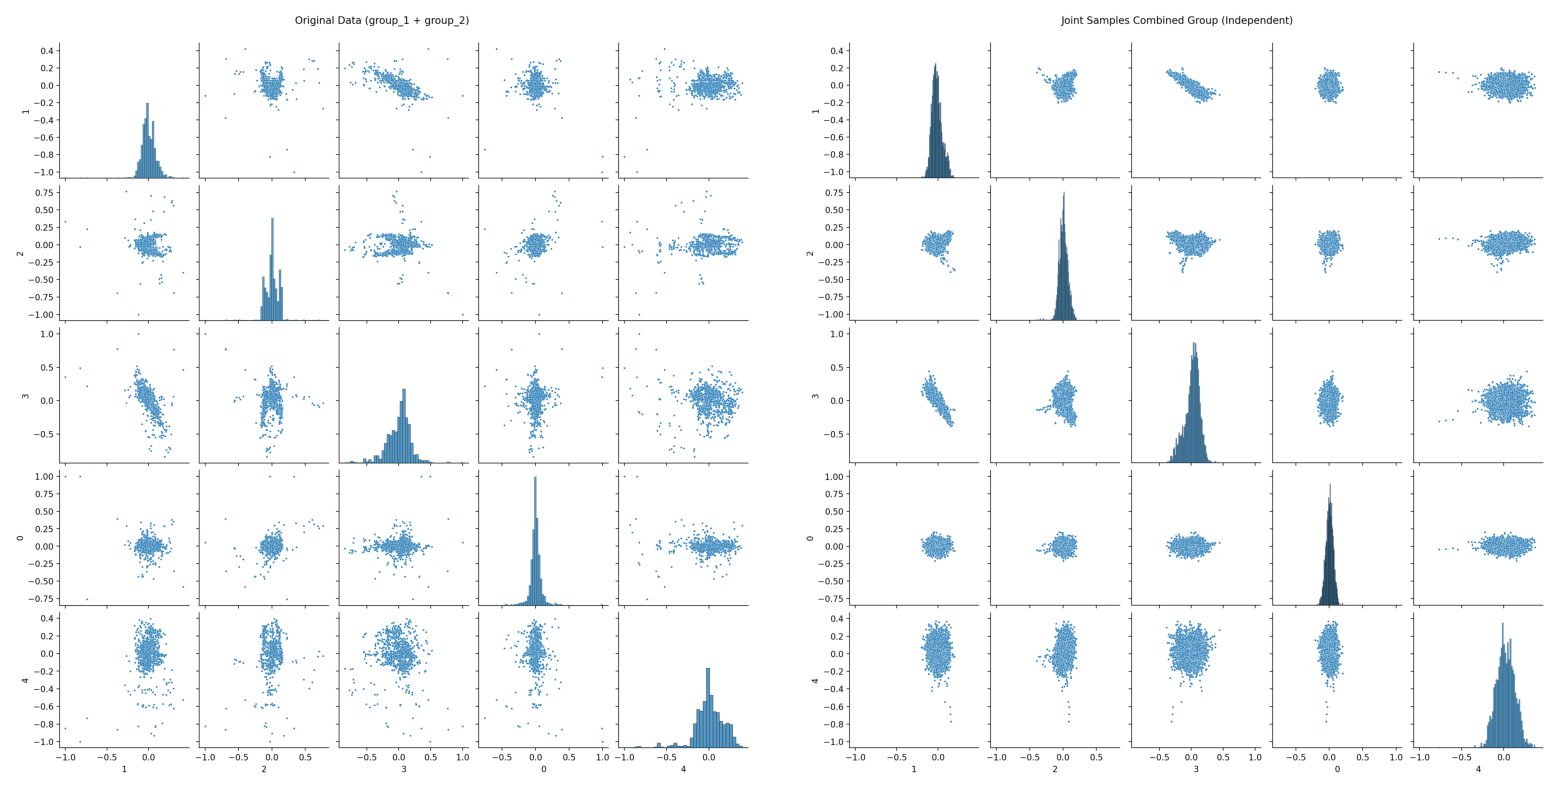

In [ ]:
import io
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the raw input data
combined_data = pd.concat(
    [group_1.reset_index(drop=True), group_2.reset_index(drop=True)],
    axis=1
)

# If needed, make samples a DataFrame with matching columns
samples_df = pd.DataFrame(samples, columns=combined_data.columns)

True_Data = combined_data
samples_plot = samples_df
name = "Joint Samples Combined Group (Independent)"

# First pairplot: original data
g1 = sns.pairplot(True_Data, plot_kws={"s": 5})
g1.fig.suptitle("Original Data (group_1 + group_2)", y=1.02)

# Save axis limits
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

# Second pairplot: samples
g2 = sns.pairplot(samples_plot, plot_kws={"s": 5})
g2.fig.suptitle(name, y=1.02)

# Apply saved limits
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

# Convert both pairplots to images
buf1 = io.BytesIO()
buf2 = io.BytesIO()

g1.fig.savefig(buf1, format="png", bbox_inches="tight", dpi=200)
g2.fig.savefig(buf2, format="png", bbox_inches="tight", dpi=200)

buf1.seek(0)
buf2.seek(0)

img1 = Image.open(buf1)
img2 = Image.open(buf2)

plt.close(g1.fig)
plt.close(g2.fig)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Dependency Optimization

In [20]:
mu,P = combine_B_blocks_reparam(B1, B2,
                             group_1, group_2,
                             degree=3, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-2,
                             n_restarts=0,
                             winsor_threshold=1e-3)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         -6.9077552789821368e+00    6.49991242e-01    
   2         -7.0381625314548808e+00    4.17313222e-01    
   3         -7.0688466269749410e+00    3.69662409e-01    
   4         -7.0763996374273104e+00    3.58375896e-01    
   5         -7.0782805429003606e+00    3.55592460e-01    
   6         -7.0792191624322811e+00    3.54207513e-01    
   7         -7.0794537027958899e+00    3.53861867e-01    
   8         -7.0794683611212879e+00    3.53840271e-01    
   9         -7.0794692772648773e+00    3.53838921e-01    
  10         -7.0794697353362350e+00    3.53838246e-01    
  11         -7.0794698498540480e+00    3.53838078e-01    
  12         -7.0794698784834988e+00    3.53838035e-01    
  13         -7.0794698927982243e+00    3.53838014e-01    
  14         -7.0794698936928944e+00    3.53838013e-01    
  15         -7.0794698939165617e+00    3.

In [21]:
true_sn_loglike_muP(group_1, group_2, mu, P, degree=3, n_grid=1000, winsor=1e-3) #smaller negative log-likelihood

np.float64(1437.1041090218623)

In [22]:
samples_dep = sample_from_joint_poly_density(group_1, group_2, mu, P, 3,
                                    num_samples=1000, burnin=200, thin=1, nwalkers=None)

100%|██████████| 1000/1000 [00:01<00:00, 746.95it/s]


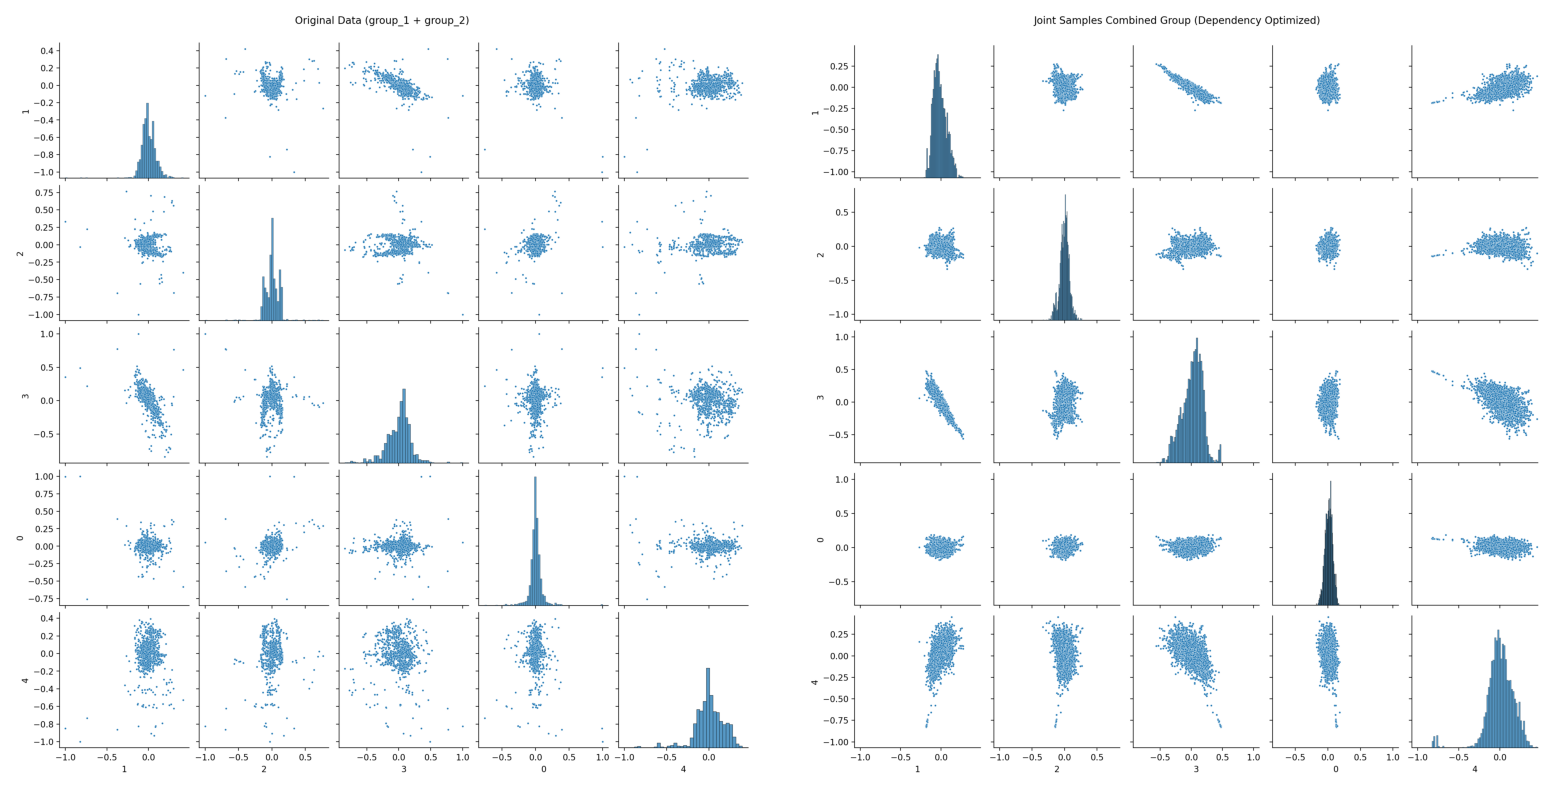

In [23]:
import io
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the raw input data
combined_data = pd.concat(
    [group_1.reset_index(drop=True), group_2.reset_index(drop=True)],
    axis=1
)

# If needed, make samples a DataFrame with matching columns
samples_df = pd.DataFrame(samples_dep, columns=combined_data.columns)

True_Data = combined_data
samples_plot = samples_df
name = "Joint Samples Combined Group (Dependency Optimized)"

# First pairplot: original data
g1 = sns.pairplot(True_Data, plot_kws={"s": 5})
g1.fig.suptitle("Original Data (group_1 + group_2)", y=1.02)

# Save axis limits
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

# Second pairplot: samples
g2 = sns.pairplot(samples_plot, plot_kws={"s": 5})
g2.fig.suptitle(name, y=1.02)

# Apply saved limits
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

# Convert both pairplots to images
buf1 = io.BytesIO()
buf2 = io.BytesIO()

g1.fig.savefig(buf1, format="png", bbox_inches="tight", dpi=200)
g2.fig.savefig(buf2, format="png", bbox_inches="tight", dpi=200)

buf1.seek(0)
buf2.seek(0)

img1 = Image.open(buf1)
img2 = Image.open(buf2)

plt.close(g1.fig)
plt.close(g2.fig)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()